<a href="https://colab.research.google.com/github/yassinemaataoui/Colab_project/blob/main/miniprojet_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTALLATION DE BASE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

UPLOAD DU FICHIER CSV

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving visionnage_series.csv to visionnage_series.csv


# **PARTIE 1**: Préparation & Nettoyage

In [ ]:
df = pd.read_csv("visionnage_series.csv")

Convertir en datetime

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['heure_debut'] = pd.to_datetime(df['heure_debut'], format="%H:%M").dt.time

Extraire jour et heure

In [ ]:
df['jour_semaine'] = df['date'].dt.day_name()
df['heure_arrondie'] = df['heure_debut'].apply(lambda x: x.hour)

Nettoyage

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

## **PARTIE 2**: Analyse temporelle

Sessions par heure

<ipython-input-22-1698a5fa5bbb>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heure_arrondie', data=df, palette='viridis')


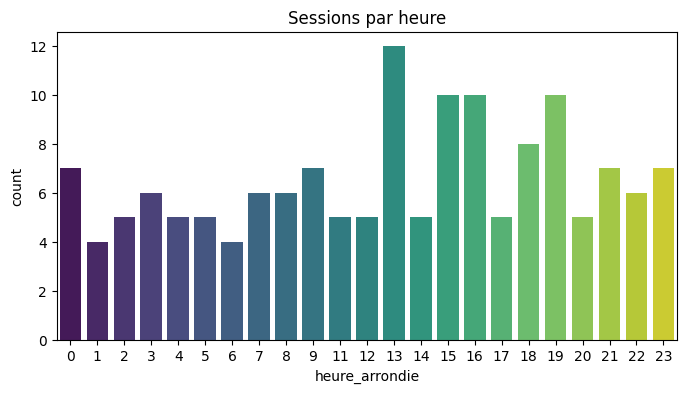

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='heure_arrondie', data=df, palette='viridis')
plt.title("Sessions par heure")
plt.show()

Sessions par jour

<ipython-input-24-d919d86d1f9b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='jour_semaine', data=df, order=jours, palette='coolwarm')


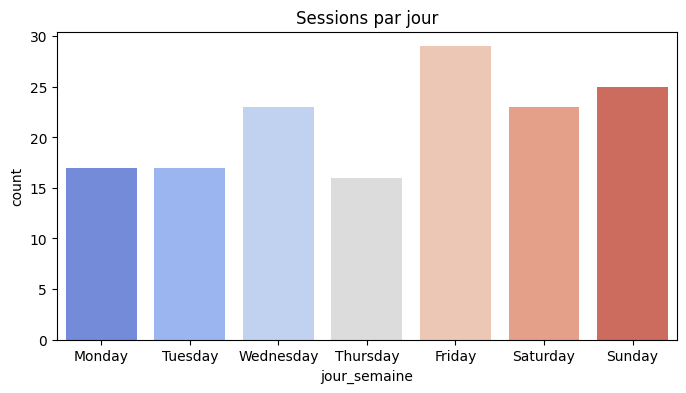

In [ ]:
jours = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(8,4))
sns.countplot(x='jour_semaine', data=df, order=jours, palette='coolwarm')
plt.title("Sessions par jour")
plt.show()

Heatmap jour vs heure

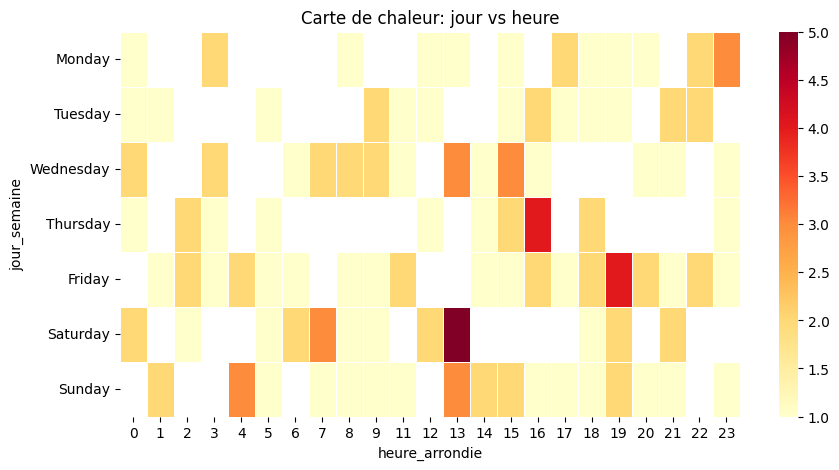

In [ ]:
pivot = df.pivot_table(index='jour_semaine', columns='heure_arrondie', values='durée', aggfunc='count')
pivot = pivot.reindex(jours)
plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5)
plt.title("Carte de chaleur: jour vs heure")
plt.show()

# **PARTIE 3**: Analyse qualitative

Série la plus vue par plateforme

In [ ]:
serie_plus_vue = df.groupby('plateforme')['série'].agg(lambda x: x.value_counts().idxmax())
print("Série la plus vue:\n", serie_plus_vue)

Série la plus vue:
 plateforme
Disney+        The Expanse
Netflix               Loki
Prime Video    Outer Banks
Name: série, dtype: object


Genre dominant

In [ ]:
genre_dominant = df.groupby('plateforme')['genre'].agg(lambda x: x.value_counts().idxmax())
print("Genre dominant:\n", genre_dominant)

Genre dominant:
 plateforme
Disney+                Comédie
Netflix        Science-fiction
Prime Video           Aventure
Name: genre, dtype: object


Durée moyenne par genre

<ipython-input-31-7a06627aa58b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=moy_duree.index, y=moy_duree.values, palette='Set2')


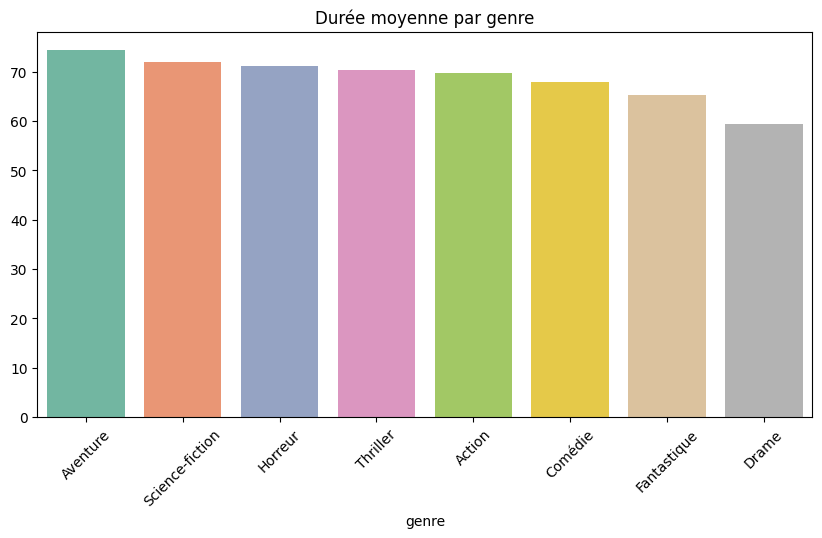

In [ ]:
moy_duree = df.groupby('genre')['durée'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=moy_duree.index, y=moy_duree.values, palette='Set2')
plt.title("Durée moyenne par genre")
plt.xticks(rotation=45)
plt.show()

# **PARTIE 4**: Comparaison inter-plateformes

In [ ]:
df['heure_int'] = df['heure_arrondie']
soir = df[(df['heure_int'] >= 18) & (df['heure_int'] <= 23)]
moyenne_soir = soir.groupby('plateforme')['durée'].mean()
print("Durée moyenne soir:\n", moyenne_soir)

Durée moyenne soir:
 plateforme
Disney+        65.750000
Netflix        78.888889
Prime Video    65.277778
Name: durée, dtype: float64


In [ ]:
longues = df[df['durée'] > 60].groupby('plateforme').size()
print("Sessions longues:\n", longues)

Sessions longues:
 plateforme
Disney+        26
Netflix        28
Prime Video    34
dtype: int64


Text(0.5, 1.0, 'Semaine vs Weekend')

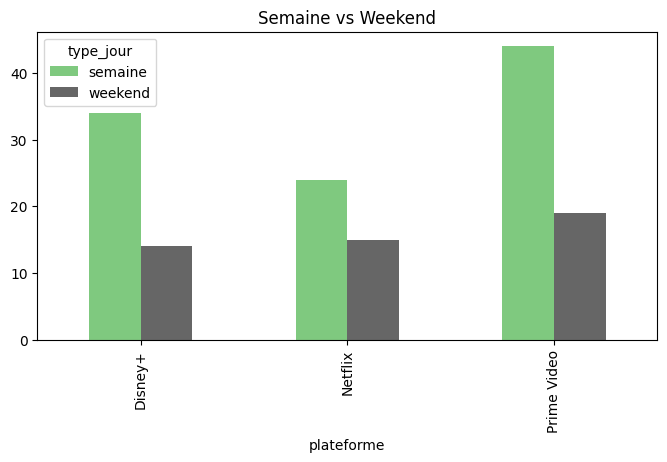

In [ ]:
def type_jour(j): return 'weekend' if j in ['Saturday','Sunday'] else 'semaine'
df['type_jour'] = df['jour_semaine'].apply(type_jour)
comparaison = df.groupby(['plateforme','type_jour']).size().unstack()
comparaison.plot(kind='bar', figsize=(8,4), colormap='Accent')
plt.title("Semaine vs Weekend")

# **PARTIE 5**: Export

In [ ]:
resultats = {
    'Série_plus_vue': serie_plus_vue,
    'Genre_dominant': genre_dominant,
    'Durée_moyenne_soir': moyenne_soir,
    'Sessions_longues': longues
}
resultats_df = pd.DataFrame(resultats)
resultats_df.to_csv("resultats_analyse.csv")

Télécharger les résultats

In [ ]:
files.download("resultats_analyse.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>